# Step 1: Read File & Feature Preparation


## Import Library


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import joblib

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from hdbscan import HDBSCAN

## Load Data


In [2]:
gc.collect()
df_Master = pd.read_parquet('df_Master_FE.parquet')
gc.collect()
print(df_Master.head(5))

                         transaction_id  item_id  quantity  unit_price  \
0  0a1b2334-f1a6-4ddc-b19d-c47cd545af23        8         3        10.0   
1  fb4facf3-e7ae-44e7-83e5-93bda146e8f2        8         3        10.0   
2  05a4dac1-9458-4703-ac1d-42fe8db33d4b        8         3        10.0   
3  fc844a9b-3ff7-45e4-8c3f-5a6b3b17fa17        8         3        10.0   
4  079b3fec-b8ac-477a-87d9-bc9a3beea036        8         3        10.0   

   subtotal     item_name menu_category  price  is_seasonal  store_id  ...  \
0      30.0  Matcha Latte    non-coffee   10.0        False         1  ...   
1      30.0  Matcha Latte    non-coffee   10.0        False         4  ...   
2      30.0  Matcha Latte    non-coffee   10.0        False         6  ...   
3      30.0  Matcha Latte    non-coffee   10.0        False         5  ...   
4      30.0  Matcha Latte    non-coffee   10.0        False         1  ...   

   month  day_name  is_weekend  member_status  is_voucher_used  month_name  \
0     11

## Struktur Data


In [3]:
gc.collect()
print(df_Master.columns.tolist())

['transaction_id', 'item_id', 'quantity', 'unit_price', 'subtotal', 'item_name', 'menu_category', 'price', 'is_seasonal', 'store_id', 'payment_method_id', 'voucher_id', 'user_id', 'original_amount', 'discount_applied', 'final_amount', 'original_amount_header', 'voucher_code', 'discount_type', 'discount_value', 'valid_from', 'valid_to', 'calculated_discount', 'gender', 'birthdate', 'registered_at', 'store_name', 'street', 'postal_code', 'city', 'state', 'latitude', 'longitude', 'created_at', 'method_name', 'payment_category', 'hour', 'month', 'day_name', 'is_weekend', 'member_status', 'is_voucher_used', 'month_name', 'transaction_period', 'discount_ratio', 'is_weekend_bool', 'is_voucher_used_bool']


In [4]:
gc.collect()
print(df_Master.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26885688 entries, 0 to 26885687
Data columns (total 47 columns):
 #   Column                  Dtype         
---  ------                  -----         
 0   transaction_id          object        
 1   item_id                 int8          
 2   quantity                int8          
 3   unit_price              float32       
 4   subtotal                float32       
 5   item_name               object        
 6   menu_category           object        
 7   price                   float32       
 8   is_seasonal             bool          
 9   store_id                int8          
 10  payment_method_id       int8          
 11  voucher_id              Int64         
 12  user_id                 Int64         
 13  original_amount         float32       
 14  discount_applied        float32       
 15  final_amount            float32       
 16  original_amount_header  float32       
 17  voucher_code            object        
 18  

## Feature Engineering : Agregasi Level Transaksi


In [5]:
# gc.collect()
# df_transaction_features = (
#     df_Master
#     .groupby('transaction_id')
#     .agg({
#         'quantity': 'sum',
#         'final_amount': 'max',
#         'discount_applied': 'max',
#         'is_weekend_bool': 'max',
#         'is_voucher_used_bool': 'max',
#         'hour': 'max',
#         'month_name': 'max',
#         'day_name': 'max',
#         'city': 'max',
#         'method_name': 'max',
#         'payment_category': 'max',
#         'member_status': 'max',
#         'created_at': 'max',
#         'user_id': 'max',
#         'transaction_period': 'max'
#     })
#     .reset_index()
#     .rename(columns={
#         'quantity': 'basket_size'
#     })
# )
# gc.collect()
# item_counts = df_Master.groupby('transaction_id')['item_id'].nunique().reset_index()
# gc.collect()
# item_counts.columns = ['transaction_id', 'item_count']
# gc.collect()
# df_transaction_features = df_transaction_features.merge(item_counts, on='transaction_id', how='left')
# gc.collect()
# print(f"Transaction features: {len(df_transaction_features):,} rows, {len(df_transaction_features.columns)} columns")

## Analisis Perilaku Pelanggan: Pembuatan Tabel RFM (`rfm_table`)


In [6]:
# gc.collect()
# snapshot_date = (
#     df_transaction_features['created_at'].max()
#     + pd.Timedelta(days=1)
# )
# gc.collect()

# rfm_table = (
#     df_transaction_features[
#         df_transaction_features['user_id'].notna()
#     ]
#     .groupby('user_id')
#     .agg(
#         Recency=('created_at', lambda x: (snapshot_date - x.max()).days),
#         Frequency=('transaction_id', 'count'),
#         Monetary=('final_amount', 'sum')
#     )
#     .reset_index()
# )
# gc.collect()

# rfm_table['is_repeat_customer'] = np.where(
#     rfm_table['Frequency'] > 1,
#     'Repeat Customer',
#     'One-Time Customer'
# )
# gc.collect()

# print(f"RFM table: {len(rfm_table):,} members")
# print(f"Snapshot date: {snapshot_date}")

## df_cluster: kolom RFM untuk clustering


In [7]:
df_transaction_features = pd.read_parquet('df_transaction_features.parquet')

In [8]:
rfm_table = pd.read_parquet('df_rfm.parquet')

In [9]:
rfm_table

,user_id,Recency,Frequency,Monetary,is_repeat_customer,RFM_Scaled_Recency,RFM_Scaled_Frequency,RFM_Scaled_Monetary
0,1,141,34,1070.474976,Repeat Customer,0.787411,11.012894,10.652255
1,2,12,40,1215.989990,Repeat Customer,-1.078331,13.167335,12.254571
2,3,86,33,1087.569946,Repeat Customer,-0.008060,10.653820,10.840493
3,4,130,25,778.500000,Repeat Customer,0.628317,7.781232,7.437218
4,5,205,40,1322.699951,Repeat Customer,1.713051,13.167335,13.429591
...,...,...,...,...,...,...,...,...
2196252,2196253,1,1,44.000000,One-Time Customer,-1.237425,-0.836531,-0.650614
2196253,2196254,1,1,30.000000,One-Time Customer,-1.237425,-0.836531,-0.804773
2196254,2196255,1,1,22.000000,One-Time Customer,-1.237425,-0.836531,-0.892864
2196255,2196256,1,1,69.000000,One-Time Customer,-1.237425,-0.836531,-0.375331


In [10]:
gc.collect()
df_cluster = rfm_table[['Recency', 'Frequency', 'Monetary']].copy()
gc.collect()
print(f"df_cluster shape: {df_cluster.shape}")

df_cluster shape: (2196257, 3)


# Step 2: Feature Transformations Pipeline


## Transformasi Data : Mengatasi Skewness dengan Log Transformation


In [11]:
gc.collect()
df_log = np.log1p(df_cluster)
print("Log1p transformation applied.")
print(df_log.head())

Log1p transformation applied.
    Recency  Frequency  Monetary
0  4.955827   3.555348  6.976791
1  2.564949   3.713572  7.104136
2  4.465908   3.526361  6.992620
3  4.875197   3.258097  6.658653
4  5.327876   3.713572  7.188186


## Validasi Distribusi: Sebelum vs. Sesudah Log Transformation


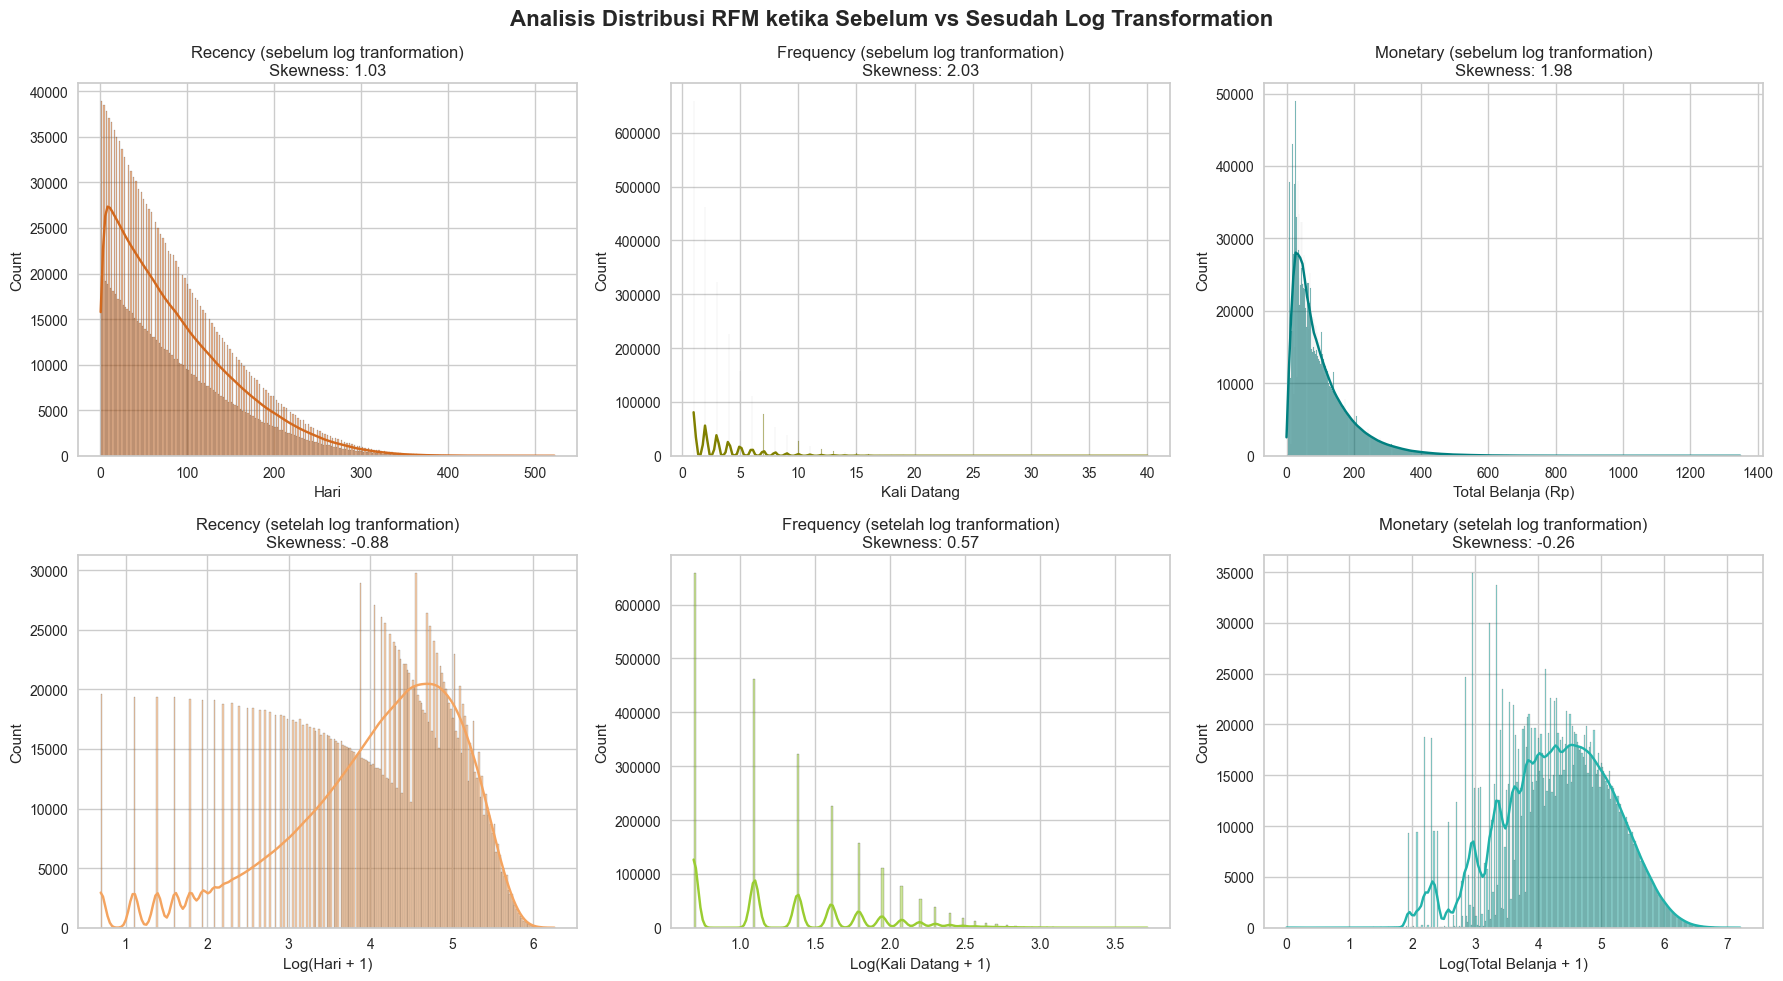


         Rekapitulasi Hasil Perubahan Skewness
Metrik RFM Skewness (Before) Skewness (After Log)
   Recency            1.0318              -0.8836
 Frequency            2.0279               0.5748
  Monetary            1.9787              -0.2644


In [12]:
gc.collect()
rfm_log = np.log1p(rfm_table[['Recency', 'Frequency', 'Monetary']])
gc.collect()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sebelum dilakukan Transformasi
sns.histplot(rfm_table['Recency'], kde=True, ax=axes[0, 0], color='chocolate')
axes[0, 0].set_title(f"Recency (sebelum log tranformation)\nSkewness: {rfm_table['Recency'].skew():.2f}", fontsize=12)
axes[0, 0].set_xlabel("Hari")
gc.collect()
sns.histplot(rfm_table['Frequency'], kde=True, ax=axes[0, 1], color='olive')
axes[0, 1].set_title(f"Frequency (sebelum log tranformation)\nSkewness: {rfm_table['Frequency'].skew():.2f}", fontsize=12)
axes[0, 1].set_xlabel("Kali Datang")
gc.collect()
sns.histplot(rfm_table['Monetary'], kde=True, ax=axes[0, 2], color='teal')
axes[0, 2].set_title(f"Monetary (sebelum log tranformation)\nSkewness: {rfm_table['Monetary'].skew():.2f}", fontsize=12)
axes[0, 2].set_xlabel("Total Belanja (Rp)")
gc.collect()
# Setelah dilakukan Transformasi
sns.histplot(rfm_log['Recency'], kde=True, ax=axes[1, 0], color='sandybrown')
axes[1, 0].set_title(f"Recency (setelah log tranformation)\nSkewness: {rfm_log['Recency'].skew():.2f}", fontsize=12)
axes[1, 0].set_xlabel("Log(Hari + 1)")
gc.collect()
sns.histplot(rfm_log['Frequency'], kde=True, ax=axes[1, 1], color='yellowgreen')
axes[1, 1].set_title(f"Frequency (setelah log tranformation)\nSkewness: {rfm_log['Frequency'].skew():.2f}", fontsize=12)
axes[1, 1].set_xlabel("Log(Kali Datang + 1)")
gc.collect()
sns.histplot(rfm_log['Monetary'], kde=True, ax=axes[1, 2], color='lightseagreen')
axes[1, 2].set_title(f"Monetary (setelah log tranformation)\nSkewness: {rfm_log['Monetary'].skew():.2f}", fontsize=12)
axes[1, 2].set_xlabel("Log(Total Belanja + 1)")
gc.collect()
plt.suptitle("Analisis Distribusi RFM ketika Sebelum vs Sesudah Log Transformation", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
gc.collect()
print("\n" + "="*50)
print("         Rekapitulasi Hasil Perubahan Skewness")
print("="*50)
gc.collect()
skew_summary = pd.DataFrame({
    'Metrik RFM': ['Recency', 'Frequency', 'Monetary'],
    'Skewness (Before)': [
        rfm_table['Recency'].skew(),
        rfm_table['Frequency'].skew(),
        rfm_table['Monetary'].skew()
    ],
    'Skewness (After Log)': [
        rfm_log['Recency'].skew(),
        rfm_log['Frequency'].skew(),
        rfm_log['Monetary'].skew()
    ]
})
gc.collect()
print(skew_summary.to_string(index=False, formatters={
    'Skewness (Before)': '{:,.4f}'.format,
    'Skewness (After Log)': '{:,.4f}'.format
}))
print("="*50)

## rfm_table_clean: subset positif untuk Box-Cox


In [13]:
gc.collect()
rfm_table_clean = rfm_table[
    (rfm_table['Recency'] > 0) &
    (rfm_table['Frequency'] > 0) &
    (rfm_table['Monetary'] > 0)
].copy()
gc.collect()
df_cluster_clean = rfm_table_clean[['Recency', 'Frequency', 'Monetary']].copy()
print(f"rfm_table_clean shape: {rfm_table_clean.shape}")

rfm_table_clean shape: (2196211, 8)


## Pipeline Transformasi: 6 Metode Scaling + Box-Cox


In [14]:
# 1. ZScore (StandardScaler)
gc.collect()
scaler_z = StandardScaler()
ZScore = pd.DataFrame(
    scaler_z.fit_transform(df_cluster[["Recency", "Frequency", "Monetary"]]),
    columns=["Recency", "Frequency", "Monetary"]
)

# 2. Log1p
gc.collect()
Log1p = np.log1p(df_cluster[["Recency", "Frequency", "Monetary"]])

# 3. Log1p + ZScore (log1p then StandardScaler)
gc.collect()
scaler_lz = StandardScaler()
LogZScore = pd.DataFrame(
    scaler_lz.fit_transform(Log1p),
    columns=["Recency", "Frequency", "Monetary"]
)

# 4. MinMax
gc.collect()
scaler_mm = MinMaxScaler()
MinMax = pd.DataFrame(
    scaler_mm.fit_transform(df_cluster[["Recency", "Frequency", "Monetary"]]),
    columns=["Recency", "Frequency", "Monetary"]
)

# 5. Yeo-Johnson
gc.collect()
scaler_yj = PowerTransformer(method='yeo-johnson', standardize=True)
YeoJohnson = pd.DataFrame(
    scaler_yj.fit_transform(df_cluster[["Recency", "Frequency", "Monetary"]]),
    columns=["Recency", "Frequency", "Monetary"]
)

# 6. QuantileTransformer
gc.collect()
scaler_qt = QuantileTransformer(output_distribution='normal', random_state=42)
Quantile = pd.DataFrame(
    scaler_qt.fit_transform(df_cluster[["Recency", "Frequency", "Monetary"]]),
    columns=["Recency", "Frequency", "Monetary"]
)

# 7. Box-Cox (positive values only)
gc.collect()
scaler_bc = PowerTransformer(method='box-cox', standardize=True)
BoxCox = pd.DataFrame(
    scaler_bc.fit_transform(df_cluster_clean[["Recency", "Frequency", "Monetary"]]),
    columns=["Recency", "Frequency", "Monetary"]
)

gc.collect()

print("All transformations complete:")
print(f"  ZScore:      {ZScore.shape}")
print(f"  Log1p:       {Log1p.shape}")
print(f"  Log+ZScore:  {LogZScore.shape}")
print(f"  MinMax:      {MinMax.shape}")
print(f"  YeoJohnson:  {YeoJohnson.shape}")
print(f"  Quantile:    {Quantile.shape}")
print(f"  BoxCox:      {BoxCox.shape}")

All transformations complete:
  ZScore:      (2196257, 3)
  Log1p:       (2196257, 3)
  Log+ZScore:  (2196257, 3)
  MinMax:      (2196257, 3)
  YeoJohnson:  (2196257, 3)
  Quantile:    (2196257, 3)
  BoxCox:      (2196211, 3)


# Step 3: Metric Evaluation (K-Means K=4)


## Elbow Method (Supplementary) pada Log+ZScore


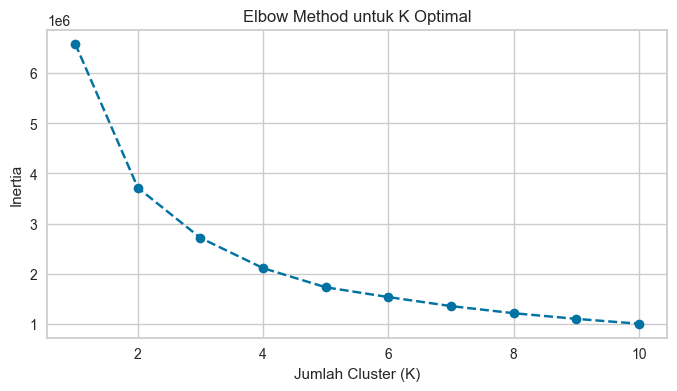

=== Tabel Hasil Pengujian Elbow Method K-Means ===
 k      inertia
 1 6,588,771.00
 2 3,713,594.07
 3 2,712,019.34
 4 2,109,356.92
 5 1,726,816.84
 6 1,531,775.76
 7 1,351,639.91
 8 1,209,609.59
 9 1,096,629.64
10   999,546.50


In [15]:
inertia = []
K_range = range(1, 11)
gc.collect()
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(LogZScore)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk K Optimal')
plt.show()
gc.collect()
df_inertia = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertia
})
gc.collect()
print("=== Tabel Hasil Pengujian Elbow Method K-Means ===")
print(df_inertia.to_string(index=False, formatters={'inertia': '{:,.2f}'.format}))

## Multi-K Silhouette/DBI (Supplementary) 


## Random Sampling & K-Means K=4 Evaluation
## Sampling 10% SRS WOR pada setiap transformasi


In [16]:
sample_fraction = 0.01
random_state = 42
gc.collect()
transform_dict = {
    'ZScore': ZScore,
    'Log1p': Log1p,
    'Log+ZScore': LogZScore,
    'MinMax': MinMax,
    'YeoJohnson': YeoJohnson,
    'Quantile': Quantile,
    'BoxCox': BoxCox
}
gc.collect()
# Sample each transformation
gc.collect()
sampled = {}
gc.collect()
for name, df_trans in transform_dict.items():
    sampled[name] = df_trans.sample(
        frac=sample_fraction,
        replace=False,
        random_state=random_state
    )
    print(f"Sampled {name}: {len(sampled[name]):,} rows")

gc.collect()
print("\nRandom sampling complete (10% SRS WOR).")

Sampled ZScore: 21,963 rows
Sampled Log1p: 21,963 rows
Sampled Log+ZScore: 21,963 rows
Sampled MinMax: 21,963 rows
Sampled YeoJohnson: 21,963 rows
Sampled Quantile: 21,963 rows
Sampled BoxCox: 21,962 rows

Random sampling complete (10% SRS WOR).


=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.3826               1.0186
 3           0.3778               0.9658
 4           0.3324               0.9280
 5           0.3370               0.9028
 6           0.3249               0.9386
 7           0.2937               0.9754
 8           0.2956               0.9616
 9           0.2976               0.9714
10           0.2964               0.9297


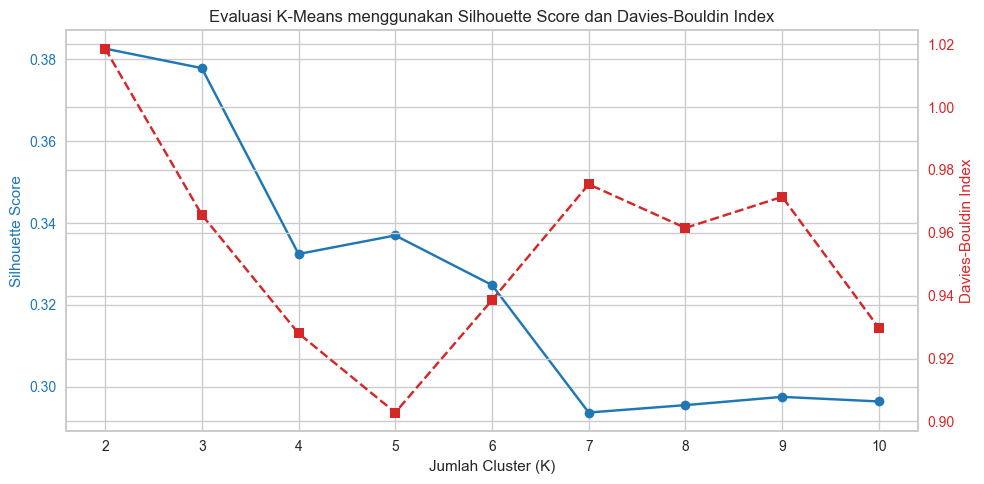

In [17]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['Log+ZScore'])

    sil_thresh = silhouette_score(sampled['Log+ZScore'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['Log+ZScore'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.4846               0.9061
 3           0.4178               0.8582
 4           0.4115               0.8448
 5           0.3685               0.9174
 6           0.3527               0.9506
 7           0.3650               0.8587
 8           0.3488               0.8940
 9           0.3490               0.8744
10           0.3355               0.8845


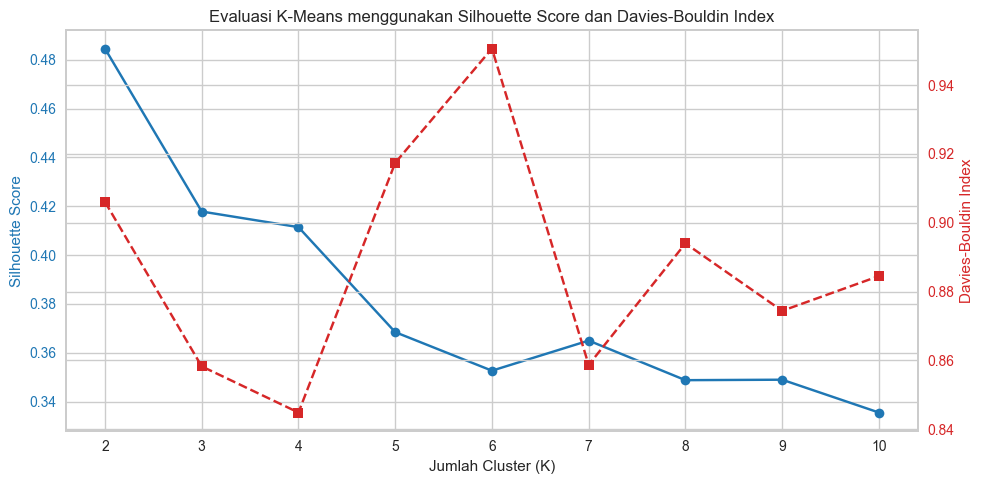

In [18]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['ZScore'])

    sil_thresh = silhouette_score(sampled['ZScore'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['ZScore'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.3495               1.1829
 3           0.3641               0.9013
 4           0.3333               0.9860
 5           0.3081               1.0285
 6           0.3164               0.8996
 7           0.3115               0.9201
 8           0.3033               0.9252
 9           0.2953               0.9406
10           0.3026               0.8867


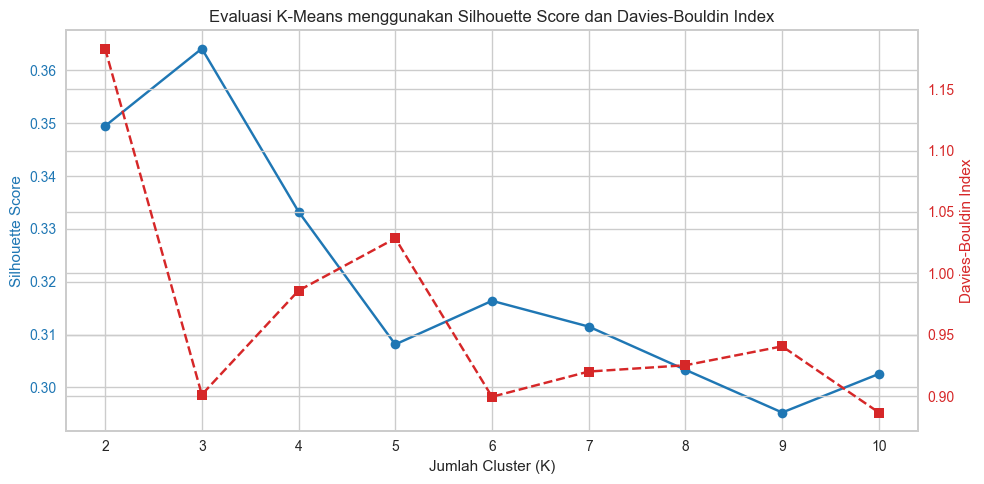

In [19]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['Log1p'])

    sil_thresh = silhouette_score(sampled['Log1p'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['Log1p'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.4535               0.9056
 3           0.4574               0.8406
 4           0.4044               0.8220
 5           0.3818               0.9110
 6           0.3917               0.8609
 7           0.3762               0.8132
 8           0.3753               0.8134
 9           0.3492               0.8478
10           0.3470               0.8541


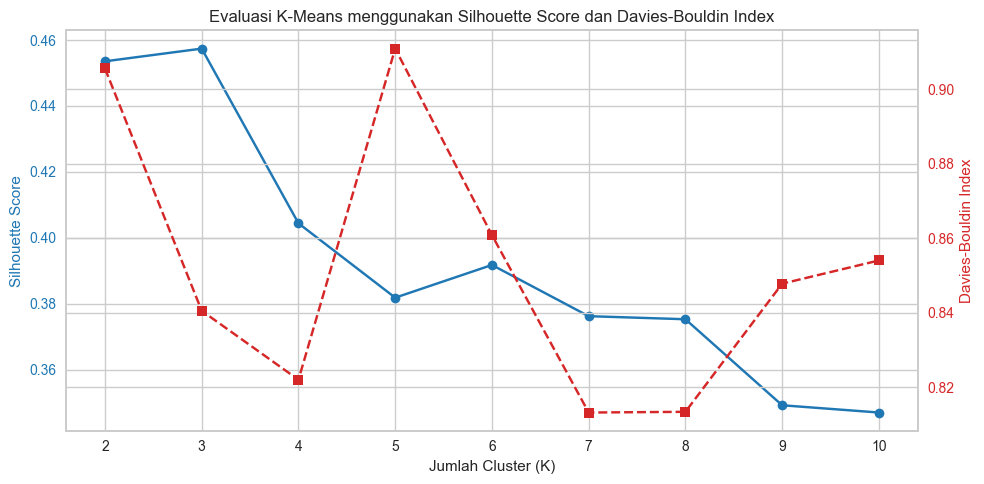

In [20]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['MinMax'])

    sil_thresh = silhouette_score(sampled['MinMax'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['MinMax'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.3858               1.0131
 3           0.3380               1.0458
 4           0.3116               1.1069
 5           0.3260               0.9347
 6           0.3200               0.9165
 7           0.3171               0.9709
 8           0.3198               0.8985
 9           0.3076               0.9532
10           0.3055               0.9478


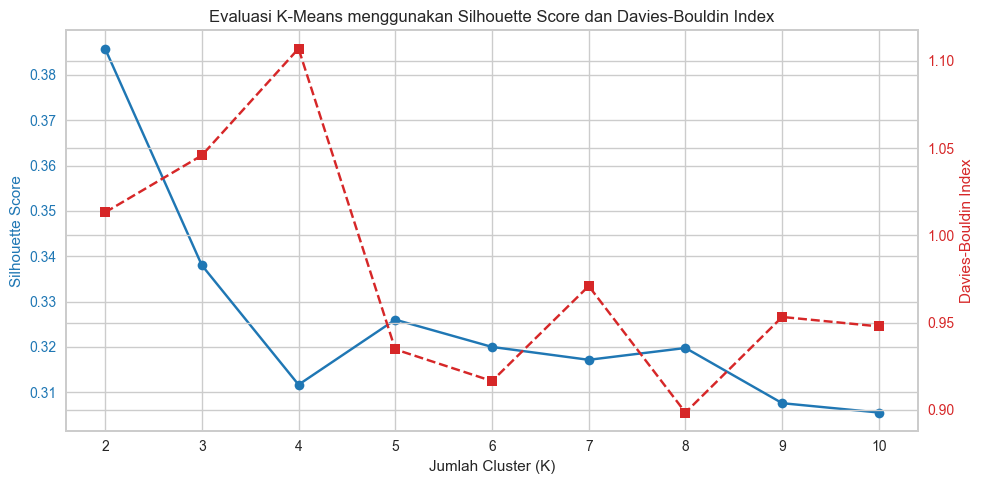

In [21]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['YeoJohnson'])

    sil_thresh = silhouette_score(sampled['YeoJohnson'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['YeoJohnson'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.7161               0.3999
 3           0.4310               0.9929
 4           0.4555               0.7952
 5           0.3530               0.9385
 6           0.3594               0.8400
 7           0.3417               0.8844
 8           0.3342               0.9071
 9           0.3306               0.8860
10           0.3119               0.8896


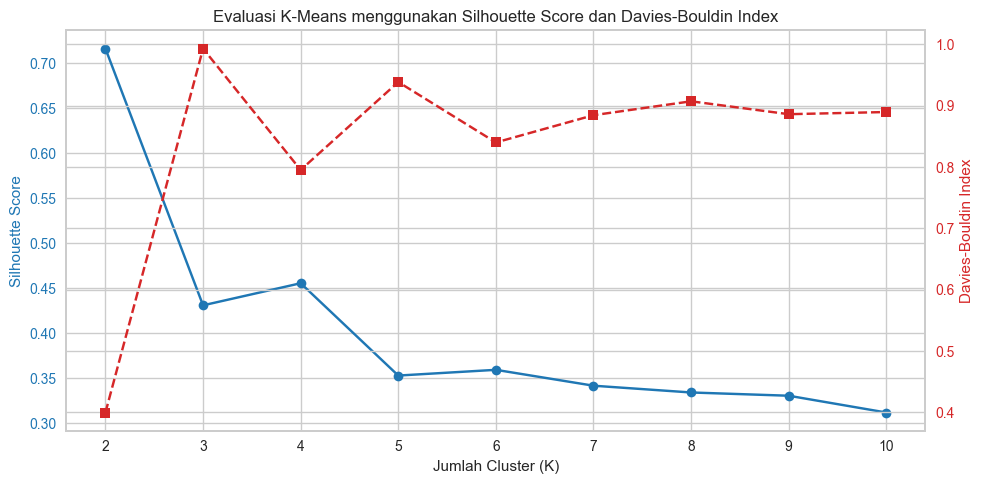

In [22]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['Quantile'])

    sil_thresh = silhouette_score(sampled['Quantile'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['Quantile'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.3842               1.0158
 3           0.3399               1.0217
 4           0.3099               1.1083
 5           0.3277               0.9401
 6           0.3211               0.9229
 7           0.3188               0.9702
 8           0.3227               0.8986
 9           0.3066               0.9527
10           0.3052               0.9482


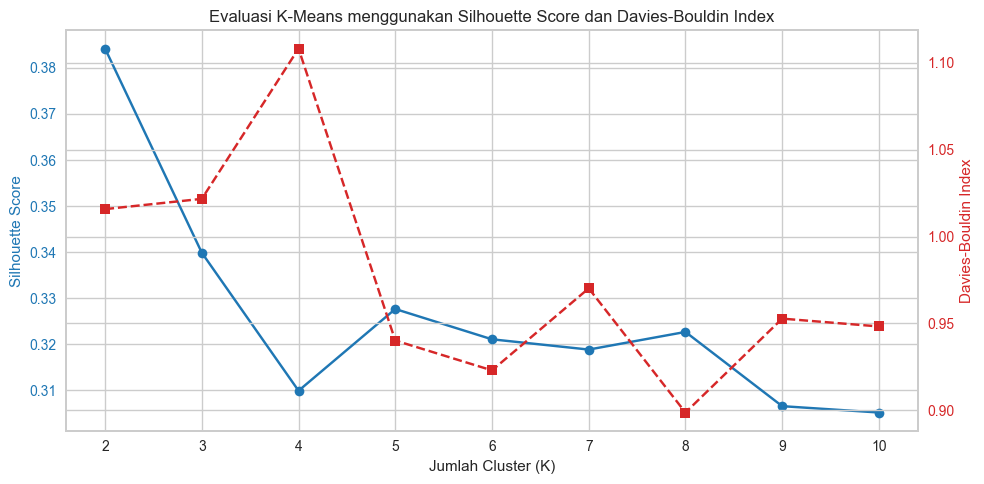

In [23]:
silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(sampled['BoxCox'])

    sil_thresh = silhouette_score(sampled['BoxCox'], labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(sampled['BoxCox'], labels)
    dbi_scores.append(dbi_thresh)
gc.collect()
df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})
gc.collect()
print("=== Data Evaluasi Metrik ===")
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))
gc.collect()
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)
gc.collect()
plt.title('Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index')
fig.tight_layout()
plt.show()

## K-Means K=4 & Metric Computation untuk Setiap Transformasi


In [24]:
results = []
optimal_k = 4
gc.collect()
for name, df_sampled in sampled.items():
    kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_sampled)

    sil = silhouette_score(df_sampled, labels)
    dbi = davies_bouldin_score(df_sampled, labels)

    results.append({
        'Transform': name,
        'Silhouette': sil,
        'DBI': dbi
    })
    print(f"{name:12s} | Silhouette: {sil:.4f} | DBI: {dbi:.4f}")
gc.collect()
df_results = pd.DataFrame(results)
gc.collect()
print("\n=== Comparison Table ===")
print(df_results.to_string(index=False))

ZScore       | Silhouette: 0.4115 | DBI: 0.8448
Log1p        | Silhouette: 0.3333 | DBI: 0.9860
Log+ZScore   | Silhouette: 0.3324 | DBI: 0.9280
MinMax       | Silhouette: 0.4044 | DBI: 0.8220
YeoJohnson   | Silhouette: 0.3116 | DBI: 1.1069
Quantile     | Silhouette: 0.4555 | DBI: 0.7952
BoxCox       | Silhouette: 0.3099 | DBI: 1.1083

=== Comparison Table ===
 Transform  Silhouette      DBI
    ZScore    0.411453 0.844832
     Log1p    0.333264 0.985993
Log+ZScore    0.332447 0.927997
    MinMax    0.404380 0.822049
YeoJohnson    0.311646 1.106947
  Quantile    0.455542 0.795211
    BoxCox    0.309909 1.108255


## Dual-Axis Visualization: Perbandingan Metrik Antar Transformasi


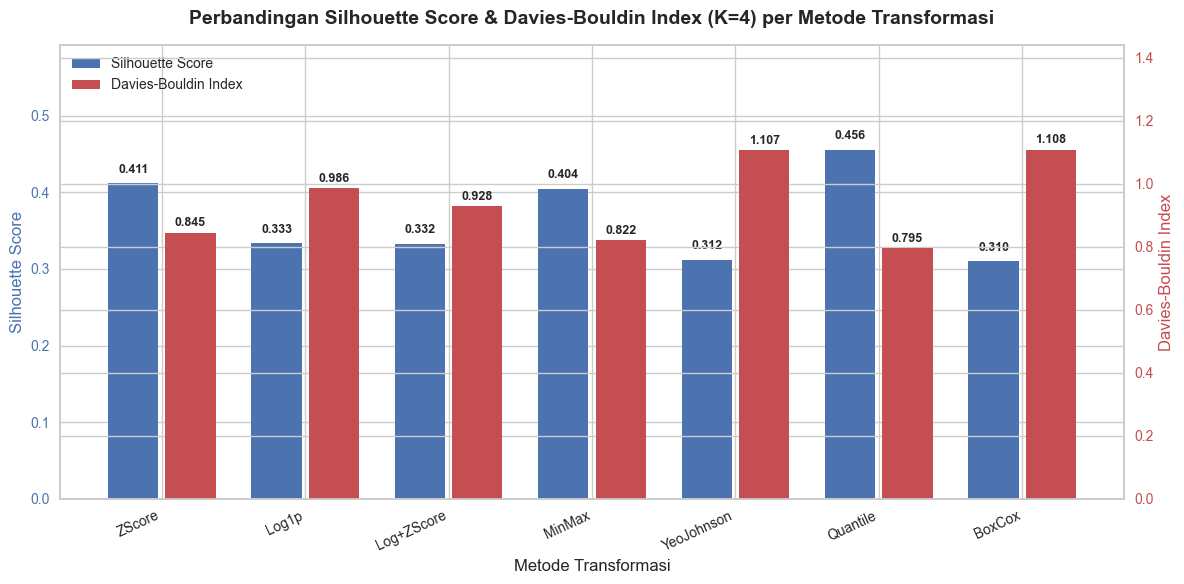


Best transform by Silhouette: Quantile
Best transform by DBI:        Quantile


In [25]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df_results))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD', '#E5825C']

bars1 = ax1.bar(x_pos - 0.2, df_results['Silhouette'], width=0.35, color='#4C72B0', label='Silhouette Score')
ax1.set_ylabel('Silhouette Score', color='#4C72B0', fontsize=12)
ax1.set_ylim(0, max(df_results['Silhouette']) * 1.3)
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
bars2 = ax2.bar(x_pos + 0.2, df_results['DBI'], width=0.35, color='#C44E52', label='Davies-Bouldin Index')
ax2.set_ylabel('Davies-Bouldin Index', color='#C44E52', fontsize=12)
ax2.set_ylim(0, max(df_results['DBI']) * 1.3)
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_results['Transform'], rotation=25, ha='right', fontsize=10)
ax1.set_xlabel('Metode Transformasi', fontsize=12)
gc.collect()
# Annotate values on bars
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Perbandingan Silhouette Score & Davies-Bouldin Index (K=4) per Metode Transformasi',
          fontsize=14, fontweight='bold', pad=15)
gc.collect()
# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Silhouette Score'),
                   Patch(facecolor='#C44E52', label='Davies-Bouldin Index')]
ax1.legend(handles=legend_elements, loc='upper left')
gc.collect()
plt.tight_layout()
plt.show()

print(f"\nBest transform by Silhouette: {df_results.loc[df_results['Silhouette'].idxmax(), 'Transform']}")
print(f"Best transform by DBI:        {df_results.loc[df_results['DBI'].idxmin(), 'Transform']}")

# Step 4: Cluster Visualization (K-Means & HDBSCAN)


## K-Means K=4 pada Transformasi Terbaik (berdasarkan Silhouette tertinggi)


In [26]:
best_transform = df_results.loc[df_results['Silhouette'].idxmax(), 'Transform']
best_df = sampled[best_transform]
gc.collect()
print(f"Using best transform: {best_transform}")
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(best_df)

# Attach cluster labels to rfm_table_sample
rfm_table_sample = rfm_table.sample(
    frac=sample_fraction,
    replace=False,
    random_state=random_state
).reset_index(drop=True)
rfm_table_sample['Cluster'] = labels

# Also store best_df for plotting
best_df_values = best_df

print(rfm_table_sample['Cluster'].value_counts().sort_index())

Using best transform: Quantile
Cluster
0    6018
1    6602
2    5199
3    4144
Name: count, dtype: int64


## Visualisasi Distribusi Anggota per Klaster


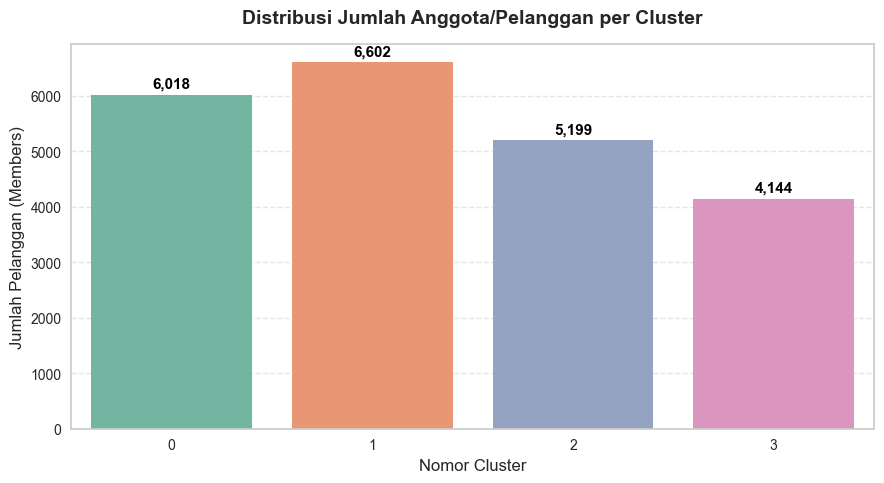

In [27]:
cluster_counts = rfm_table_sample['Cluster'].value_counts().sort_index()

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    palette='Set2',
    hue=cluster_counts.index,
    legend=False
)

for p in ax.patches:
    ax.annotate(
        text=f'{int(p.get_height()):,}',
        xy=(p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='baseline',
        fontsize=11,
        fontweight='bold',
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.title('Distribusi Jumlah Anggota/Pelanggan per Cluster', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nomor Cluster', fontsize=12)
plt.ylabel('Jumlah Pelanggan (Members)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Visualisasi Ruang Geometris 3D Klaster & Centroid


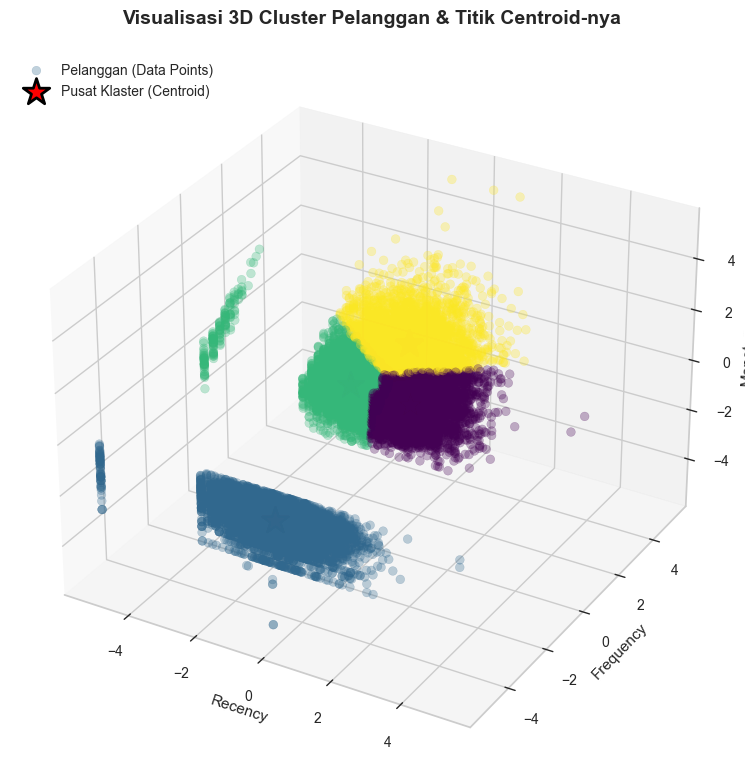

In [28]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = best_df_values['Recency']
y = best_df_values['Frequency']
z = best_df_values['Monetary']

scatter = ax.scatter(x, y, z, c=rfm_table_sample['Cluster'], cmap='viridis', s=40, alpha=0.3)

centroids = kmeans.cluster_centers_

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    marker='*',
    s=400,
    c='red',
    edgecolor='black',
    linewidth=2,
    label='Centroid'
)

ax.set_xlabel('Recency')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary')
plt.title('Visualisasi 3D Cluster Pelanggan & Titik Centroid-nya', fontsize=14, fontweight='bold', pad=20)
plt.legend(['Pelanggan (Data Points)', 'Pusat Klaster (Centroid)'], loc='upper left')
plt.tight_layout()
plt.show()

## PCA 2D Visualization


In [29]:
pca = PCA(n_components=2, random_state=42)

pca_data = pca.fit_transform(best_df_values)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

centroids_3d = kmeans.cluster_centers_
centroids_2d = pca.transform(centroids_3d)

explained_variance = pca.explained_variance_ratio_ * 100
print(f"Informasi yang dipertahankan oleh PC1: {explained_variance[0]:.2f}%")
print(f"Informasi yang dipertahankan oleh PC2: {explained_variance[1]:.2f}%")
print(f"Total informasi 3D yang terangkum di 2D: {sum(explained_variance):.2f}%")

Informasi yang dipertahankan oleh PC1: 83.75%
Informasi yang dipertahankan oleh PC2: 12.83%
Total informasi 3D yang terangkum di 2D: 96.58%


c:\Users\Jeremmy\LocalProjects\Python_Things\.venv312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


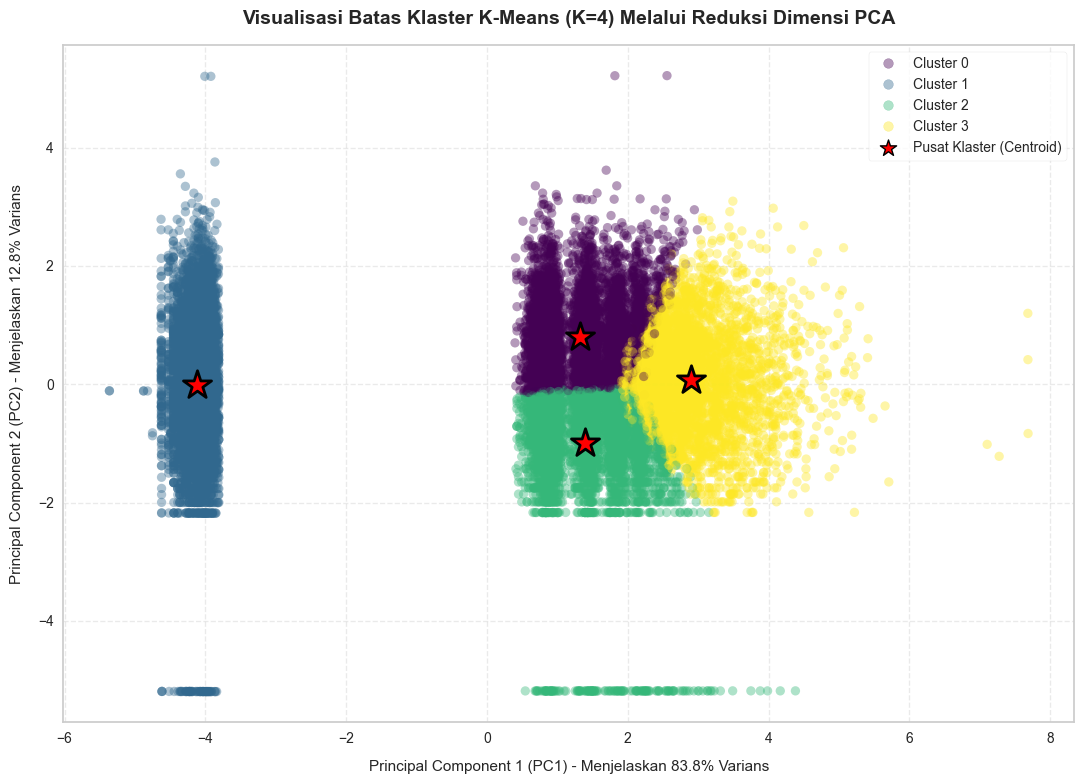

In [30]:
fig, ax = plt.subplots(figsize=(11, 8))

cluster_labels = rfm_table_sample['Cluster']
scatter = ax.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=cluster_labels,
    cmap='viridis',
    s=45,
    alpha=0.4,
    edgecolors='none'
)

ax.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    marker='*',
    s=450,
    c='red',
    edgecolor='black',
    linewidth=2,
    label='Centroid (Pusat Klaster)'
)

ax.set_xlabel(f'Principal Component 1 (PC1) - Menjelaskan {explained_variance[0]:.1f}% Varians', fontsize=11, labelpad=10)
ax.set_ylabel(f'Principal Component 2 (PC2) - Menjelaskan {explained_variance[1]:.1f}% Varians', fontsize=11, labelpad=10)

plt.title('Visualisasi Batas Klaster K-Means (K=4) Melalui Reduksi Dimensi PCA', fontsize=14, fontweight='bold', pad=15)

handles, _ = scatter.legend_elements(prop="colors")
legend_labels = [f'Cluster {i}' for i in range(optimal_k)]
legend_labels.append('Pusat Klaster (Centroid)')

centroid_handle = ax.scatter([], [], marker='*', s=150, c='red', edgecolor='black', linewidth=1)
all_handles = handles + [centroid_handle]

ax.legend(all_handles, legend_labels, loc='upper right', frameon=True, facecolor='white', edgecolor='gainsboro')

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## HDBSCAN Clustering (Alternatif)


In [80]:
clusterer = HDBSCAN(
    min_cluster_size=1200,
    min_samples=65,
    metric='euclidean',
    core_dist_n_jobs=-1,
    prediction_data=True
)

hdb_labels = clusterer.fit_predict(best_df_values)
print(f"HDBSCAN clusters found: {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}")
print(f"Noise points: {list(hdb_labels).count(-1)}")

HDBSCAN clusters found: 4
Noise points: 2141


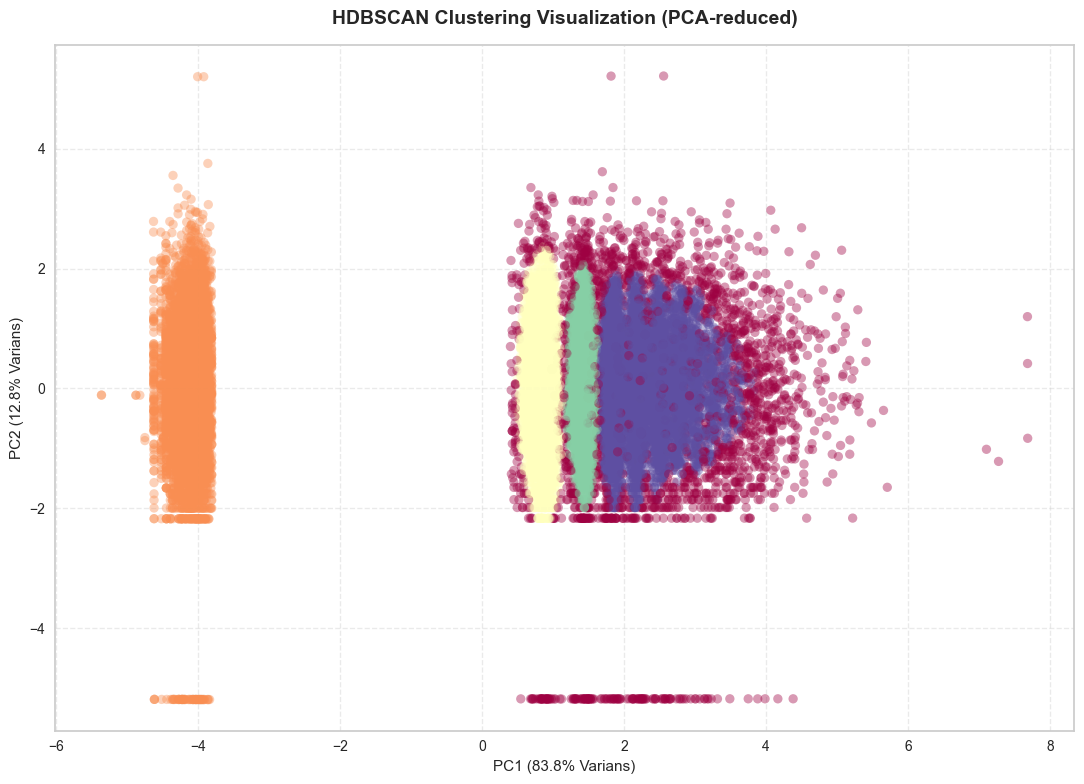

In [81]:
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    df_pca['PC1'],
    df_pca['PC2'],
    c=hdb_labels,
    cmap='Spectral',
    s=45,
    alpha=0.4,
    edgecolors='none'
)

plt.title('HDBSCAN Clustering Visualization (PCA-reduced)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'PC1 ({explained_variance[0]:.1f}% Varians)', fontsize=11)
plt.ylabel(f'PC2 ({explained_variance[1]:.1f}% Varians)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [82]:
gc.collect()
print("HDBSCAN complete.")

HDBSCAN complete.


# Step 5: Remaining Explorations


## Profiling Klaster Melalui Menghitung Karakteristik Rata-Rata RFM


In [83]:
cluster_profile = rfm_table_sample.groupby('Cluster').agg(
    R_Mean=('Recency', 'mean'),
    F_Mean=('Frequency', 'mean'),
    M_Mean=('Monetary', 'mean'),
    Total_Pelanggan=('user_id', 'count')
).reset_index()

print(cluster_profile)

   Cluster      R_Mean    F_Mean      M_Mean  Total_Pelanggan
0        0  138.641409  2.976570   88.201790             6018
1        1   86.911996  1.000000   30.899204             6602
2        2   27.241777  3.142912   94.892876             5199
3        3   84.652751  7.779681  247.963593             4144


## Proses Labeling Segmen Pelanggan


In [84]:
cluster_labels = {
    0: 'Champions',
    1: 'Lost Customers',
    2: 'New Customers',
    3: 'At Risk'
}

cluster_profile['Cluster_Label'] = cluster_profile['Cluster'].map(cluster_labels)
column_order = ['Cluster', 'Cluster_Label', 'R_Mean', 'F_Mean', 'M_Mean', 'Total_Pelanggan']
cluster_profile = cluster_profile[column_order]
print(cluster_profile)

   Cluster   Cluster_Label      R_Mean    F_Mean      M_Mean  Total_Pelanggan
0        0       Champions  138.641409  2.976570   88.201790             6018
1        1  Lost Customers   86.911996  1.000000   30.899204             6602
2        2   New Customers   27.241777  3.142912   94.892876             5199
3        3         At Risk   84.652751  7.779681  247.963593             4144


In [85]:
cluster_profile

,Cluster,Cluster_Label,R_Mean,F_Mean,M_Mean,Total_Pelanggan
0,0,Champions,138.641409,2.976570,88.201790,6018
1,1,Lost Customers,86.911996,1.000000,30.899204,6602
2,2,New Customers,27.241777,3.142912,94.892876,5199
3,3,At Risk,84.652751,7.779681,247.963593,4144


## Analisis Komposisi & Validasi Karakteristik Tiap Segmen


In [86]:
for cluster_id in sorted(rfm_table_sample['Cluster'].unique()):
    nama_label = cluster_labels.get(cluster_id, "Tanpa Label")
    df_filtered = rfm_table_sample[rfm_table_sample['Cluster'] == cluster_id][['user_id', 'Recency', 'Frequency', 'Monetary']]

    print(f"\n" + "="*75)
    print(f" DATAFRAME SAMPLE: CLUSTER {cluster_id} - {nama_label}")
    print(f" Total Anggota: {len(df_filtered)} Pelanggan")
    print(f"="*75)

    print(df_filtered.head(5))


 DATAFRAME SAMPLE: CLUSTER 0 - Champions
 Total Anggota: 6018 Pelanggan
    user_id  Recency  Frequency    Monetary
3    311963      119          3  109.500000
5    854269      157          2   63.500000
8    919781       74          3   90.000000
13   634511      202          3   99.000000
19   535024      154          4   78.809998

 DATAFRAME SAMPLE: CLUSTER 1 - Lost Customers
 Total Anggota: 6602 Pelanggan
   user_id  Recency  Frequency  Monetary
0  2132630       11          1       9.0
1  1227327      164          1      56.0
6  1459618      125          1      14.0
7  1692306       85          1      19.0
9  2149682        8          1      56.0

 DATAFRAME SAMPLE: CLUSTER 2 - New Customers
 Total Anggota: 5199 Pelanggan
    user_id  Recency  Frequency    Monetary
2   1278446       43          3  147.500000
4    704294       20          4  149.000000
10  1534363       23          2   62.720001
18   883073       35          5  143.500000
23  1918845       14          2   52.00000

In [87]:
loyalty_composition = pd.crosstab(
    rfm_table_sample['Cluster'].map(cluster_labels),
    rfm_table_sample['is_repeat_customer'],
    normalize='index'
) * 100

print("=== Komposisi Loyalitas per Cluster (%) ===")
print(loyalty_composition.round(1))

=== Komposisi Loyalitas per Cluster (%) ===
is_repeat_customer  One-Time Customer  Repeat Customer
Cluster                                               
At Risk                           0.0            100.0
Champions                         0.0            100.0
Lost Customers                  100.0              0.0
New Customers                     0.0            100.0


## Visualisasi Komposisi Loyalitas Pelanggan per Segmen


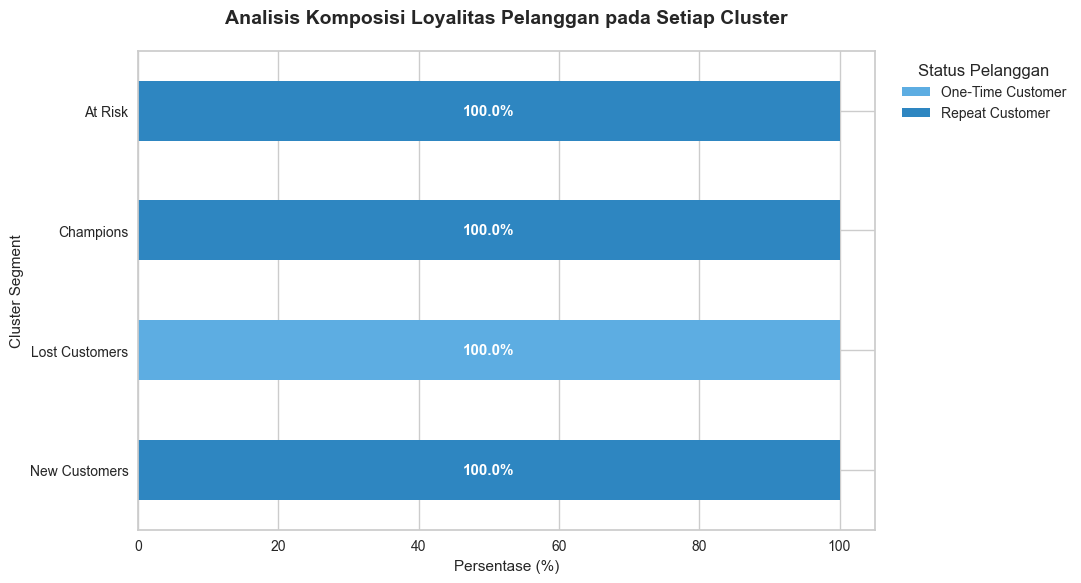

In [88]:
ax = loyalty_composition.plot(
    kind='barh',
    stacked=True,
    figsize=(11, 6),
    color=['#5DADE2', '#2E86C1']
)

for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()

    if width > 0:
        ax.text(
            x + width/2,
            y + height/2,
            f'{width:.1f}%',
            va='center',
            ha='center',
            color='white',
            fontweight='bold',
            fontsize=11
        )

plt.title('Analisis Komposisi Loyalitas Pelanggan pada Setiap Cluster', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Persentase (%)', fontsize=11)
plt.ylabel('Cluster Segment', fontsize=11)
plt.gca().invert_yaxis()
plt.legend(title='Status Pelanggan', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Analisis Kontribusi Finansial & Pangsa Pasar per Segmen


In [89]:
total_omset_kafe = rfm_table_sample['Monetary'].sum()

revenue_share = rfm_table_sample.groupby('Cluster').agg(
    Jumlah_Pelanggan=('user_id', 'count'),
    Total_Pengeluaran=('Monetary', 'sum'),
    Kontribusi_Omset_Persen=('Monetary', lambda x: (x.sum() / total_omset_kafe) * 100)
).reset_index()

revenue_share['Cluster_Label'] = revenue_share['Cluster'].map(cluster_labels)
column_order = ['Cluster', 'Cluster_Label', 'Jumlah_Pelanggan', 'Total_Pengeluaran', 'Kontribusi_Omset_Persen']
revenue_share = revenue_share[column_order]

print("=== Analisis Kontribusi Finansial Cluster ===")
print(revenue_share.round(2))

=== Analisis Kontribusi Finansial Cluster ===
   Cluster   Cluster_Label  Jumlah_Pelanggan  Total_Pengeluaran  \
0        0       Champions              6018       5.307984e+05   
1        1  Lost Customers              6602       2.039965e+05   
2        2   New Customers              5199       4.933481e+05   
3        3         At Risk              4144       1.027561e+06   

   Kontribusi_Omset_Persen  
0                    23.53  
1                     9.04  
2                    21.87  
3                    45.55  


## Perbandingan Strategis: Porsi Populasi vs. Kontribusi Omset per Segmen


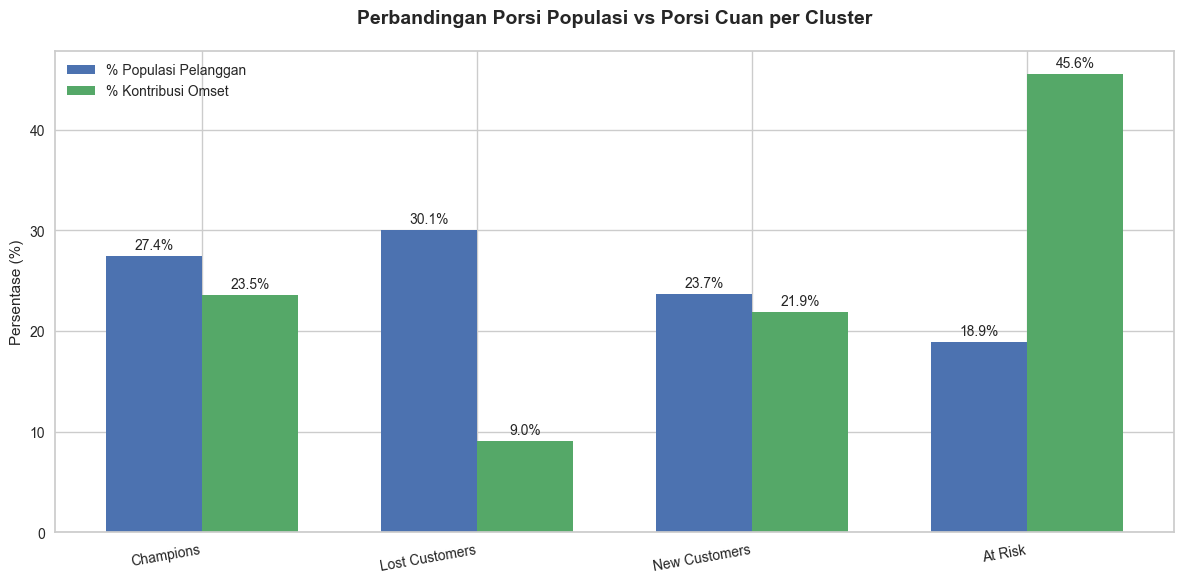

In [90]:
total_pelanggan = revenue_share['Jumlah_Pelanggan'].sum()
revenue_share['Populasi_Pelanggan_Persen'] = (revenue_share['Jumlah_Pelanggan'] / total_pelanggan) * 100

labels = revenue_share['Cluster_Label']
pop_pct = revenue_share['Populasi_Pelanggan_Persen']
rev_pct = revenue_share['Kontribusi_Omset_Persen']

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, pop_pct, width, label='% Populasi Pelanggan', color='#4C72B0')
rects2 = ax.bar(x + width/2, rev_pct, width, label='% Kontribusi Omset', color='#55A868')

ax.set_ylabel('Persentase (%)', fontsize=11)
ax.set_title('Perbandingan Porsi Populasi vs Porsi Cuan per Cluster', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha='right', fontsize=10)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.1f%%', fontsize=10)
ax.bar_label(rects2, padding=3, fmt='%.1f%%', fontsize=10)

plt.tight_layout()
plt.show()

## Analisis Distribusi Segmen Pelanggan per Cabang Toko


In [91]:
rfm_table_sample['Cluster_Label'] = rfm_table_sample['Cluster'].map(cluster_labels)

df_prescriptive = df_transaction_features.merge(
    rfm_table_sample[['user_id', 'Cluster_Label']],
    on='user_id',
    how='inner'
)

store_cluster_summary = (
    df_prescriptive
    .groupby(['city', 'Cluster_Label'])
    .size()
    .to_frame(name='Jumlah')
)

print("=== Ringkasan Distribusi Karakteristik Pelanggan per Cabang ===")
print(store_cluster_summary)

=== Ringkasan Distribusi Karakteristik Pelanggan per Cabang ===
                                     Jumlah
city                 Cluster_Label         
Alam Tun Hussein Onn At Risk           3166
                     Champions         1785
                     Lost Customers     621
                     New Customers     1725
Bandar Seri Mulia    At Risk           3200
                     Champions         1755
                     Lost Customers     692
                     New Customers     1569
Damansara Saujana    At Risk           3234
                     Champions         1827
                     Lost Customers     651
                     New Customers     1658
Kampung Changkat     At Risk           3193
                     Champions         1773
                     Lost Customers     671
                     New Customers     1603
Kondominium Putra    At Risk           3182
                     Champions         1760
                     Lost Customers     615
            

## Pola Pelanggan: Hari Kerja vs Akhir Pekan


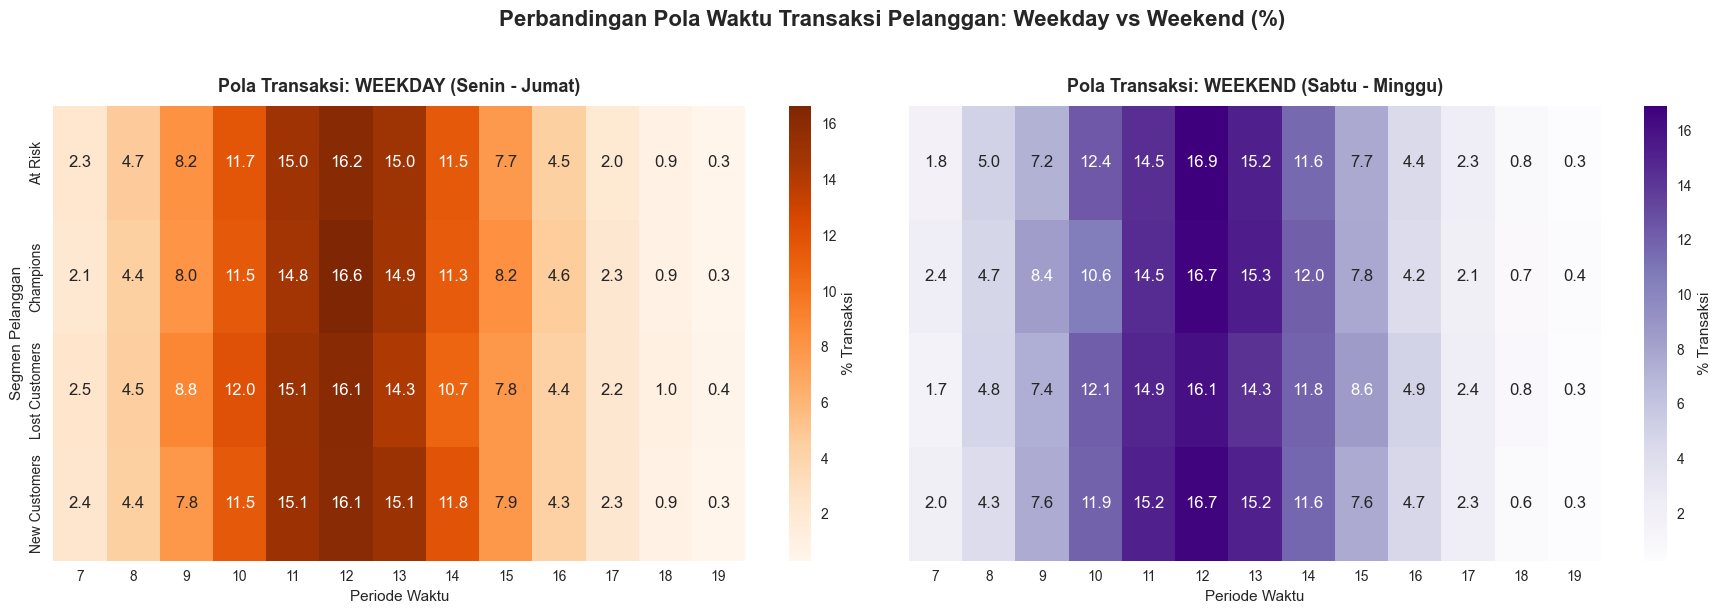

In [92]:
df_weekday = df_prescriptive[df_prescriptive['is_weekend_bool'] == 0]
df_weekend = df_prescriptive[df_prescriptive['is_weekend_bool'] == 1]

matrix_weekday = pd.crosstab(df_weekday['Cluster_Label'], df_weekday['hour'], normalize='index') * 100
matrix_weekend = pd.crosstab(df_weekend['Cluster_Label'], df_weekend['hour'], normalize='index') * 100

custom_order = ['Morning', 'Afternoon', 'Evening', 'Night', 'Late Night']
available_cols_wd = [col for col in custom_order if col in matrix_weekday.columns]
available_cols_we = [col for col in custom_order if col in matrix_weekend.columns]

# matrix_weekday = matrix_weekday.reindex(columns=available_cols_wd)
# matrix_weekend = matrix_weekend.reindex(columns=available_cols_we)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.heatmap(matrix_weekday, cmap='Oranges', annot=True, fmt='.1f', ax=axes[0], cbar_kws={'label': '% Transaksi'})
axes[0].set_title('Pola Transaksi: WEEKDAY (Senin - Jumat)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Periode Waktu', fontsize=11)
axes[0].set_ylabel('Segmen Pelanggan', fontsize=11)

sns.heatmap(matrix_weekend, cmap='Purples', annot=True, fmt='.1f', ax=axes[1], cbar_kws={'label': '% Transaksi'})
axes[1].set_title('Pola Transaksi: WEEKEND (Sabtu - Minggu)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Periode Waktu', fontsize=11)
axes[1].set_ylabel('')

plt.suptitle('Perbandingan Pola Waktu Transaksi Pelanggan: Weekday vs Weekend (%)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Otomatisasi Rekomendasi Promo Berbasis Jendela Waktu dan Batas Kedaluwarsa


In [93]:
df_prescriptive.head(0)


,transaction_id,basket_size,final_amount,discount_applied,is_weekend_bool,is_voucher_used_bool,hour,month_name,day_name,city,method_name,payment_category,member_status,created_at,user_id,transaction_period,item_count,Cluster_Label


In [94]:
historical_logic = df_Master[df_Master['discount_ratio'] > 0]['discount_ratio']

avg_disc = historical_logic.mean() * 100
max_disc = historical_logic.max() * 100

print(f"Rata-rata diskon historis: {avg_disc:.1f}%")
print(f"Batas diskon tertinggi: {max_disc:.1f}%")

Rata-rata diskon historis: 12.3%
Batas diskon tertinggi: 100.0%


In [95]:
df_prescriptive['Cluster_Label'] 

0               At Risk
1               At Risk
2               At Risk
3               At Risk
4               At Risk
              ...      
73089     New Customers
73090     New Customers
73091     New Customers
73092    Lost Customers
73093     New Customers
Name: Cluster_Label, Length: 73094, dtype: object

In [96]:

def generate_final_prescriptive_engine(df_input, avg_disc, max_disc):
    recommendations = []
    
    # Kalkulasi angka diskon dinamis (Audit Historis)
    at_risk_val = min(int(avg_disc * 1.2), int(max_disc)) 
    new_cust_val = int(avg_disc)
    lost_cust_val = int(max_disc)

    grouped = df_input.groupby(['city', 'Cluster_Label', 'is_weekend_bool', 'hour']).size().reset_index(name='tx_count')
    
    for city in sorted(df_input['city'].unique()):
        df_city = grouped[grouped['city'] == city]
        for is_weekend in [0, 1]:
            df_day_type = df_city[df_city['is_weekend_bool'] == is_weekend]
            tipe_hari = "Weekend" if is_weekend == 1 else "Weekday"
            
            for segmen in df_input['Cluster_Label'].unique():
                df_segmen = df_day_type[df_day_type['Cluster_Label'] == segmen]
                if df_segmen.empty: continue
                
                top_row = df_segmen.loc[df_segmen['tx_count'].idxmax()]
                peak_hour = int(top_row['hour'])
                
                # Windowing & Trigger
                start_w, end_w = (peak_hour - 1) % 24, (peak_hour + 1) % 24
                trigger_h = (peak_hour - 2) % 24
                
                # Heuristik Produk Terlaris
                df_context = df_input[(df_input['city'] == city) & 
                                     (df_input['is_weekend_bool'] == is_weekend) & 
                                     (df_input['hour'] == peak_hour)]
                top_items = df_context['user_id'].value_counts().index[:2].tolist()
                item_1 = top_items[0] if len(top_items) > 0 else "Kopi Signature"
                item_2 = top_items[1] if len(top_items) > 1 else "Snack Favorit"

                # Penulisan logika teks strategi (Sudah lurus spasinya)
                if segmen == 'Champions':
                    disc = 0
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Jam puncak transaksi (Peak Hour) segmen ini berada pada pukul {peak_hour:02d}:00.\n"
                                f"2. Berikan apresiasi berupa 'Gratis Naik Ukuran' (Size Upgrade) untuk menu {item_1}.\n"
                                f"3. Penerapan langsung di kasir pada jendela waktu jam {start_w:02d}:00 - {end_w:02d}:00.\n"
                                f"4. Hal ini bertujuan mengunci loyalitas tanpa memotong harga jual di saat toko sedang ramai.")
                
                elif segmen == 'At Risk':
                    disc = at_risk_val
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Jam puncak transaksi historis kelompok ini terdeteksi pada pukul {peak_hour:02d}:00.\n"
                                f"2. Kirim voucher digital potongan harga sebesar {disc}% untuk menu {item_1}.\n"
                                f"3. Kirim notifikasi jam {trigger_h:02d}:00 (H-1 sebelum jendela waktu promo {start_w:02d}:00-{end_w:02d}:00 dibuka).\n"
                                f"4. Hal ini bertujuan Mencegat pelanggan agar kembali mampir ke toko sebelum jam ramai mereka dimulai.")
                
                elif segmen == 'New Customers':
                    disc = new_cust_val
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Lonjakan kunjungan dari pelanggan baru tercatat pada pukul {peak_hour:02d}:00.\n"
                                f"2. Aktifkan promo hemat paket bundling ({item_1} + {item_2}) dengan diskon {disc}%.\n"
                                f"3. Tampilkan di banner aplikasi selama rentang jam {start_w:02d}:00 - {end_w:02d}:00.\n"
                                f"4. Hal ini untuk menaikkan nilai rata-rata keranjang belanja (Average Basket Size) selagi mereka berada di toko.")
                
                else: # Lost Customers
                    disc = lost_cust_val
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Waktu kunjungan potensial terakhir mereka sebelum pasif adalah pukul {peak_hour:02d}:00.\n"
                                f"2. Lakukan penawaran agresif dengan diskon maksimal {disc}% untuk paket {item_1} + {item_2}.\n"
                                f"3. Kirim SMS / direst message pada jam {trigger_h:02d}:00 (Masa aktif kupon jam {start_w:02d}:00 - {end_w:02d}:00).\n"
                                f"4. Menarik kembali perhatian pelanggan lama yang sudah pasif agar mereka mau berkunjung kembali ke Cabang {city}.")
                
                # Memasukkan hasil ke list (Sudah dibersihkan dari Tab)
                recommendations.append({
                    'Cabang': city,
                    'Tipe Hari': tipe_hari,
                    'Target Segmen': segmen,
                    'Rentang Jam': f"{start_w:02d}:00 - {end_w:02d}:00",
                    'Diskon (%)': disc,
                    'Bentuk_Insentif': "Free Upgrade" if segmen == 'Champions (Coffee Addicts)' else "Potongan Harga",
                    'Strategy_Text': strategy
                })
                
    return pd.DataFrame(recommendations)

# Eksekusi ulang engine
df_final_engine = generate_final_prescriptive_engine(df_prescriptive, avg_disc, max_disc)


In [97]:

def generate_final_prescriptive_engine(df_input, avg_disc, max_disc):
    recommendations = []
    
    # Kalkulasi angka diskon dinamis (Audit Historis)
    at_risk_val = min(int(avg_disc * 1.2), int(max_disc)) 
    new_cust_val = int(avg_disc)
    lost_cust_val = int(max_disc)

    grouped = df_input.groupby(['city', 'Cluster_Label', 'is_weekend_bool', 'hour']).size().reset_index(name='tx_count')
    
    for city in sorted(df_input['city'].unique()):
        df_city = grouped[grouped['city'] == city]
        for is_weekend in [0, 1]:
            df_day_type = df_city[df_city['is_weekend_bool'] == is_weekend]
            tipe_hari = "Weekend" if is_weekend == 1 else "Weekday"
            
            for segmen in df_input['Cluster_Label'].unique():
                df_segmen = df_day_type[df_day_type['Cluster_Label'] == segmen]
                if df_segmen.empty: continue
                
                top_row = df_segmen.loc[df_segmen['tx_count'].idxmax()]
                peak_hour = int(top_row['hour'])
                
                # Windowing & Trigger
                start_w, end_w = (peak_hour - 1) % 24, (peak_hour + 1) % 24
                trigger_h = (peak_hour - 2) % 24
                
                # Heuristik Produk Terlaris
                df_context = df_input[(df_input['city'] == city) & 
                                     (df_input['is_weekend_bool'] == is_weekend) & 
                                     (df_input['hour'] == peak_hour)]
                top_items = df_context['user_id'].value_counts().index[:2].tolist()
                item_1 = top_items[0] if len(top_items) > 0 else "Kopi Signature"
                item_2 = top_items[1] if len(top_items) > 1 else "Snack Favorit"

                # Penulisan logika teks strategi (Sudah lurus spasinya)
                if segmen == 'Champions (Coffee Addicts)':
                    disc = 0
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Jam puncak transaksi (Peak Hour) segmen ini berada pada pukul {peak_hour:02d}:00.\n"
                                f"2. Berikan apresiasi berupa 'Gratis Naik Ukuran' (Size Upgrade) untuk menu {item_1}.\n"
                                f"3. Penerapan langsung di kasir pada jendela waktu jam {start_w:02d}:00 - {end_w:02d}:00.\n"
                                f"4. Hal ini bertujuan mengunci loyalitas tanpa memotong harga jual di saat toko sedang ramai.")
                
                elif segmen == 'At Risk (Fading Regulars)':
                    disc = at_risk_val
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Jam puncak transaksi historis kelompok ini terdeteksi pada pukul {peak_hour:02d}:00.\n"
                                f"2. Kirim voucher digital potongan harga sebesar {disc}% untuk menu {item_1}.\n"
                                f"3. Kirim notifikasi jam {trigger_h:02d}:00 (H-1 sebelum jendela waktu promo {start_w:02d}:00-{end_w:02d}:00 dibuka).\n"
                                f"4. Hal ini bertujuan Mencegat pelanggan agar kembali mampir ke toko sebelum jam ramai mereka dimulai.")
                
                elif segmen == 'New Customers':
                    disc = new_cust_val
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Lonjakan kunjungan dari pelanggan baru tercatat pada pukul {peak_hour:02d}:00.\n"
                                f"2. Aktifkan promo hemat paket bundling ({item_1} + {item_2}) dengan diskon {disc}%.\n"
                                f"3. Tampilkan di banner aplikasi selama rentang jam {start_w:02d}:00 - {end_w:02d}:00.\n"
                                f"4. Hal ini untuk menaikkan nilai rata-rata keranjang belanja (Average Basket Size) selagi mereka berada di toko.")
                
                else: # Lost Customers
                    disc = lost_cust_val
                    strategy = (f"Rekomendasi yang diberikan:\n"
                                f"1. Waktu kunjungan potensial terakhir mereka sebelum pasif adalah pukul {peak_hour:02d}:00.\n"
                                f"2. Lakukan penawaran agresif dengan diskon maksimal {disc}% untuk paket {item_1} + {item_2}.\n"
                                f"3. Kirim SMS / direst message pada jam {trigger_h:02d}:00 (Masa aktif kupon jam {start_w:02d}:00 - {end_w:02d}:00).\n"
                                f"4. Menarik kembali perhatian pelanggan lama yang sudah pasif agar mereka mau berkunjung kembali ke Cabang {city}.")
                
                # Memasukkan hasil ke list (Sudah dibersihkan dari Tab)
                recommendations.append({
                    'Cabang': city,
                    'Tipe Hari': tipe_hari,
                    'Target Segmen': segmen,
                    'Rentang Jam': f"{start_w:02d}:00 - {end_w:02d}:00",
                    'Diskon (%)': disc,
                    'Bentuk_Insentif': "Free Upgrade" if segmen == 'Champions (Coffee Addicts)' else "Potongan Harga",
                    'Strategy_Text': strategy
                })
                
    return pd.DataFrame(recommendations)

# Eksekusi ulang engine
df_final_engine = generate_final_prescriptive_engine(df_prescriptive, avg_disc, max_disc)


In [98]:
display(df_final_engine)

,Cabang,Tipe Hari,Target Segmen,Rentang Jam,Diskon (%),Bentuk_Insentif,Strategy_Text
0,Alam Tun Hussein Onn,Weekday,At Risk,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
1,Alam Tun Hussein Onn,Weekday,Champions,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
2,Alam Tun Hussein Onn,Weekday,New Customers,11:00 - 13:00,12,Potongan Harga,Rekomendasi yang diberikan:\n1. Lonjakan kunju...
3,Alam Tun Hussein Onn,Weekday,Lost Customers,10:00 - 12:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
4,Alam Tun Hussein Onn,Weekend,At Risk,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
...,...,...,...,...,...,...,...
75,USJ 89q,Weekday,Lost Customers,12:00 - 14:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
76,USJ 89q,Weekend,At Risk,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
77,USJ 89q,Weekend,Champions,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
78,USJ 89q,Weekend,New Customers,10:00 - 12:00,12,Potongan Harga,Rekomendasi yang diberikan:\n1. Lonjakan kunju...


In [99]:
# Untuk melihat 5 baris pertama hasil rekomendasi

display(df_final_engine.head())



# Atau kalau mau melihat semua rekomendasi untuk satu cabang tertentu (misal Store_01)

display(df_final_engine[df_final_engine['Cabang'] == 'Store_01'])




# Simpan hasil rekomendasi ke file Excel

df_final_engine.to_excel("Rekomendasi_Strategi_Kafe.xlsx", index=False)

print("File sukses disimpan, Lif!")

,Cabang,Tipe Hari,Target Segmen,Rentang Jam,Diskon (%),Bentuk_Insentif,Strategy_Text
0,Alam Tun Hussein Onn,Weekday,At Risk,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
1,Alam Tun Hussein Onn,Weekday,Champions,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
2,Alam Tun Hussein Onn,Weekday,New Customers,11:00 - 13:00,12,Potongan Harga,Rekomendasi yang diberikan:\n1. Lonjakan kunju...
3,Alam Tun Hussein Onn,Weekday,Lost Customers,10:00 - 12:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...
4,Alam Tun Hussein Onn,Weekend,At Risk,11:00 - 13:00,99,Potongan Harga,Rekomendasi yang diberikan:\n1. Waktu kunjunga...


,Cabang,Tipe Hari,Target Segmen,Rentang Jam,Diskon (%),Bentuk_Insentif,Strategy_Text


File sukses disimpan, Lif!


In [100]:
# ==============================================================================================
# ini diletakkan di setelah cell Pola Pelanggan: Hari Kerja vs Akhir Pekan (beda cell)
# jadi Otomatisasi Rekomendasi Promo Berbasis Jendela Waktu dan Batas Kedaluwarsa codenya
# dihapus, diganti ikut pipeline/alur dibawah ini jadinya
# ======================================================================================

# (Markdown) : Batas Pengendalian Insentif Finansial (Historical Benchmarking)



# ==================================================================================
# beda cell
# ==================================================================================

# (Markdown) : Kerangka Kerja Analitik Preskriptif

# ==================================================================================
# beda cell
# ==================================================================================

# # (Markdown) : Simulasi Dampak Finansial & Estimasi Alokasi Anggaran Promosi

# # 1. Hitung rata-rata omset (final_amount) per Cabang, Hari, dan Jam dari data historis
# historical_revenue = df_prescriptive.groupby(['city', 'is_weekend_bool', 'hour'])['final_amount'].mean().reset_index()
# historical_revenue.columns = ['Cabang', 'is_weekend_bool', 'hour', 'Avg_Revenue']

# # 2. Siapkan data rekomendasi (ambil kolom yang dibutuhkan saja)
# df_rekap = df_final_engine.copy()

# # 3. Konversi kembali kolom jam agar bisa di-join
# df_rekap['hour'] = df_rekap['Rentang Jam'].str[:2].astype(int)
# df_rekap['is_weekend_bool'] = df_rekap['Tipe Hari'].map({'Weekend': 1, 'Weekday': 0})

# # 4. Gabungkan (Merge) rekomendasi dengan rata-rata omset historis
# df_rekap = df_rekap.merge(historical_revenue, on=['Cabang', 'is_weekend_bool', 'hour'], how='left')

# # 5. Hitung Estimasi Biaya Diskon (Konversi string '25%' menjadi float 0.25)
# df_rekap['Discount_Pct'] = df_rekap['Diskon (%)'].str.replace('%', '').astype(float) / 100
# df_rekap['Est_Discount_Cost'] = df_rekap['Avg_Revenue'] * df_rekap['Discount_Pct']

# # 6. Rekap per Cabang
# summary_branch = df_rekap.groupby('Cabang')['Est_Discount_Cost'].sum().reset_index()
# print("=== Estimasi Alokasi Anggaran Diskon per Cabang ===")
# display(summary_branch)

# 1. Hitung rata-rata omset (final_amount) per Cabang, Hari, dan Jam dari data historis
historical_revenue = df_prescriptive.groupby(['city', 'is_weekend_bool', 'hour'])['final_amount'].mean().reset_index()
historical_revenue.columns = ['Cabang', 'is_weekend_bool', 'hour', 'Avg_Revenue']

# 2. Siapkan data rekomendasi (Gunakan DataFrame hasil output engine terbaru)
df_rekap = df_final_engine.copy()

# 3. Konversi kembali kolom jam agar bisa di-join (Mengambil 2 angka pertama dari '07:00 - 09:00')
df_rekap['hour'] = df_rekap['Rentang Jam'].str[:2].astype(int)
df_rekap['is_weekend_bool'] = df_rekap['Tipe Hari'].map({'Weekend': 1, 'Weekday': 0})

# 4. Gabungkan (Merge) rekomendasi dengan rata-rata omset historis
df_rekap = df_rekap.merge(historical_revenue, on=['Cabang', 'is_weekend_bool', 'hour'], how='left')

# 5. Hitung Estimasi Biaya Diskon (Lebih simpel karena sudah berupa angka otomatis)
df_rekap['Discount_Pct'] = df_rekap['Diskon (%)'] / 100
df_rekap['Est_Discount_Cost'] = df_rekap['Avg_Revenue'] * df_rekap['Discount_Pct']

# 6. Rekap per Cabang
summary_branch = df_rekap.groupby('Cabang')['Est_Discount_Cost'].sum().round(2).reset_index()

print("=== Estimasi Alokasi Anggaran Diskon per Cabang ===")
display(summary_branch)

=== Estimasi Alokasi Anggaran Diskon per Cabang ===


,Cabang,Est_Discount_Cost
0,Alam Tun Hussein Onn,192.52
1,Bandar Seri Mulia,190.85
2,Damansara Saujana,187.36
3,Kampung Changkat,190.01
4,Kondominium Putra,194.88
5,PJS8,194.07
6,Seksyen 21,191.54
7,Taman Damansara,187.54
8,USJ 57W,188.90
9,USJ 89q,192.31


In [101]:
gc.collect()
print('Notebook execution complete.')

Notebook execution complete.
